In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle

In [2]:
df = pd.read_csv('../data_folder/Bitcoin_history_data.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


## Créer la target (prix monte dans 5 jours)


In [ ]:
df["future_close"] = df["Close"].shift(-5)
df["target"] = (df["future_close"] > df["Close"]).astype(int)
df = df.dropna()

## Sélection des features

In [ ]:
features = ["Open", "High", "Low", "Close", "Volume"]

X = df[features]
y = df["target"]


## Split temporel 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

## Standardisation

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

## Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

In [ ]:
# Export the pipeline as a pickle file
with open('../models/linear_regression_1.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
# Load the pipeline
with open('../models/linear_regression_1.pkl', 'rb') as file:
    model = pickle.load(file)

In [ ]:
from app.ai_for_finance import my_prediction_function

my_prediction_function(
    0,0,0,0,0
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

df2 = pd.read_csv('../data_folder/Bitcoin_history_data.csv')
df2.columns = df2.columns.str.strip()
df2['Date'] = pd.to_datetime(df2['Date'])
df2 = df2.resample('ME', on='Date').last()

colors = ['#1D9E75' if df2['Close'].iloc[i] >= df2['Close'].iloc[i-1] else '#E24B4A'
          for i in range(len(df2))]

fig = plt.figure(figsize=(14, 9), facecolor='#0f0f0f')
gs = gridspec.GridSpec(3, 1, height_ratios=[4, 1, 1], hspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax1.plot(df2.index, df2['Close'], color='#378ADD', linewidth=1.5)
ax1.fill_between(df2.index, df2['Close'], alpha=0.08, color='#378ADD')
ax1.set_facecolor('#0f0f0f')
ax1.tick_params(colors='gray', labelsize=8)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax1.set_title('Bitcoin — prix de clôture, volume, RSI', color='white', fontsize=12, pad=12)
for spine in ax1.spines.values(): spine.set_color('#333')

ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.bar(df2.index, df2['Volume'], color=colors, width=20, alpha=0.8)
ax2.set_facecolor('#0f0f0f')
ax2.tick_params(colors='gray', labelsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))
for spine in ax2.spines.values(): spine.set_color('#333')

delta = df2['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rsi = 100 - (100 / (1 + gain/loss))

ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(df2.index, rsi, color='#7F77DD', linewidth=1.2)
ax3.axhline(70, color='#E24B4A', linewidth=0.7, linestyle='--', alpha=0.5)
ax3.axhline(30, color='#1D9E75', linewidth=0.7, linestyle='--', alpha=0.5)
ax3.set_ylim(0, 100)
ax3.set_facecolor('#0f0f0f')
ax3.tick_params(colors='gray', labelsize=8)
for spine in ax3.spines.values(): spine.set_color('#333')

plt.savefig('btc_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

In [ ]:
# Volatilité rolling (écart-type des rendements journaliers, annualisé)
df2_daily = pd.read_csv('../data_folder/Bitcoin_history_data.csv')
df2_daily.columns = df2_daily.columns.str.strip()
df2_daily['Date'] = pd.to_datetime(df2_daily['Date'])
df2_daily = df2_daily.set_index('Date')

df2_daily['return_1d'] = df2_daily['Close'].pct_change()
df2_daily['vol_30d'] = df2_daily['return_1d'].rolling(30).std() * np.sqrt(365) * 100
df2_daily['vol_10d'] = df2_daily['return_1d'].rolling(10).std() * np.sqrt(365) * 100

vol_monthly = df2_daily[['vol_30d', 'vol_10d']].resample('ME').last()

fig, ax = plt.subplots(figsize=(14, 3), facecolor='#0f0f0f')
ax.plot(vol_monthly.index, vol_monthly['vol_30d'], color='#EF9F27', linewidth=1.5, label='Vol 30j')
ax.plot(vol_monthly.index, vol_monthly['vol_10d'], color='#888780', linewidth=1, linestyle='--', label='Vol 10j')
ax.fill_between(vol_monthly.index, vol_monthly['vol_30d'], alpha=0.1, color='#EF9F27')
ax.set_facecolor('#0f0f0f')
ax.tick_params(colors='gray', labelsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(facecolor='#1a1a1a', labelcolor='gray', fontsize=8)
ax.set_title('Volatilité annualisée (rolling)', color='white', fontsize=11)
for spine in ax.spines.values(): spine.set_color('#333')
plt.tight_layout()
plt.show()

In [ ]:
# Corrélation prix vs volatilité
merged = df2_daily[['Close', 'vol_30d']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#0f0f0f')

# Scatter prix vs vol
ax = axes[0]
sc = ax.scatter(merged['Close'], merged['vol_30d'],
                c=merged.index.year, cmap='plasma',
                alpha=0.4, s=8)
ax.set_facecolor('#0f0f0f')
ax.tick_params(colors='gray', labelsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlabel('Prix de clôture', color='gray', fontsize=9)
ax.set_ylabel('Volatilité 30j annualisée', color='gray', fontsize=9)
ax.set_title('Prix vs volatilité', color='white', fontsize=11)
for spine in ax.spines.values(): spine.set_color('#333')
plt.colorbar(sc, ax=ax, label='Année').ax.yaxis.label.set_color('gray')

# Corrélation rolling dans le temps
corr_rolling = merged['Close'].rolling(180).corr(merged['vol_30d'])

ax2 = axes[1]
ax2.plot(corr_rolling.index, corr_rolling, color='#7F77DD', linewidth=1.2)
ax2.axhline(0, color='#888780', linewidth=0.7, linestyle='--')
ax2.fill_between(corr_rolling.index, corr_rolling, 0,
                 where=corr_rolling > 0, alpha=0.15, color='#1D9E75')
ax2.fill_between(corr_rolling.index, corr_rolling, 0,
                 where=corr_rolling < 0, alpha=0.15, color='#E24B4A')
ax2.set_ylim(-1, 1)
ax2.set_facecolor('#0f0f0f')
ax2.tick_params(colors='gray', labelsize=8)
ax2.set_title('Corrélation rolling 180j (prix × vol)', color='white', fontsize=11)
ax2.set_ylabel('Pearson r', color='gray', fontsize=9)
for spine in ax2.spines.values(): spine.set_color('#333')

corr_global = merged['Close'].corr(merged['vol_30d'])
fig.suptitle(f'Corrélation globale Pearson : {corr_global:.3f}',
             color='white', fontsize=10, y=1.01)

plt.tight_layout()
plt.show()
print(f"Corrélation globale : {corr_global:.3f}")

In [3]:
from app.ml_logic.data import get_financial_data

data = get_financial_data(
    tickers=['BTC-USD', 'ETH-USD', 'SPY'],
    period_years=10
)

df_btc = data['BTC-USD']
df_btc.head()

[BTC-USD] cache à jour (3654 lignes)
[ETH-USD] cache à jour (3078 lignes)
[SPY] cache à jour (2517 lignes)


,Open,High,Low,Close,Volume
Date,,,,,
2016-04-12,422.842987,427.277008,422.842987,425.190002,70728800
2016-04-13,425.631989,426.657990,422.915985,423.734009,69060400
2016-04-14,423.934998,425.371002,423.013000,424.282013,45281000
2016-04-15,424.427002,429.928009,424.427002,429.713013,54801500
2016-04-16,429.575012,432.625000,428.984009,430.571991,39392800


In [4]:
import ipywidgets as widgets
from IPython.display import display
from app.ml_logic.data import get_financial_data

ticker_dropdown = widgets.Dropdown(
    options=[('Bitcoin', 'BTC-USD'), ('Ethereum', 'ETH-USD'), ('S&P 500', '^GSPC')],
    value='BTC-USD',
    description='Actif :'
)

years_dropdown = widgets.Dropdown(
    options=[('1 an', 1), ('3 ans', 3), ('5 ans', 5), ('10 ans', 10)],
    value=5,
    description='Période :'
)

button = widgets.Button(description='Télécharger', button_style='primary')
output = widgets.Output()

def on_click(b):
    output.clear_output()
    with output:
        print(f"Téléchargement {ticker_dropdown.label} — {years_dropdown.label}...")
        data = get_financial_data(tickers=[ticker_dropdown.value], period_years=years_dropdown.value)
        global df
        df = data[ticker_dropdown.value]
        print(f"Période : {df.index[0].date()} → {df.index[-1].date()}")
        print(f"Lignes  : {len(df)}")
        display(df.tail())

button.on_click(on_click)
display(widgets.VBox([ticker_dropdown, years_dropdown, button, output]))

In [6]:
# Features engineering sur le df sélectionné
def compute_features(df):
    df = df.copy()

    # RSI
    delta = df['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    df['rsi'] = 100 - (100 / (1 + gain/loss))

    # MACD
    ema12 = df['Close'].ewm(span=12).mean()
    ema26 = df['Close'].ewm(span=26).mean()
    df['macd'] = ema12 - ema26
    df['macd_hist'] = df['macd'] - df['macd'].ewm(span=9).mean()

    # Returns & vol
    df['return_1d'] = df['Close'].pct_change()
    df['return_5d'] = df['Close'].pct_change(5)
    df['return_10d'] = df['Close'].pct_change(10)
    df['volatility_10'] = df['return_1d'].rolling(10).std()
    df['volatility_30'] = df['return_1d'].rolling(30).std()
    df['vol_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()

    # Target
    df['target'] = (df['Close'].shift(-5) > df['Close']).astype(int)

    return df.dropna()

# Training
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

df_feat = compute_features(df)

features = ['rsi', 'macd', 'macd_hist', 'return_1d', 'return_5d',
            'return_10d', 'volatility_10', 'volatility_30', 'vol_ratio']

X = df_feat[features]
y = df_feat['target']

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.03,
                      subsample=0.8, colsample_bytree=0.8,
                      random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Ticker  : {ticker_dropdown.label}")
print(f"Période : {years_dropdown.label}")
print(f"Accuracy: {accuracy:.4f}")

Ticker  : Bitcoin
Période : 10 ans
Accuracy: 0.5172


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import itertools

def compute_features_extended(df):
    df = df.copy()
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date')
    df.index = pd.to_datetime(df.index)

    # RSI multi-timeframe
    for period in [7, 14, 21]:
        delta = df['Close'].diff()
        gain = delta.clip(lower=0).rolling(period).mean()
        loss = -delta.clip(upper=0).rolling(period).mean()
        df[f'rsi_{period}'] = 100 - (100 / (1 + gain/loss))

    # MACD
    ema12 = df['Close'].ewm(span=12).mean()
    ema26 = df['Close'].ewm(span=26).mean()
    df['macd'] = ema12 - ema26
    df['macd_hist'] = df['macd'] - df['macd'].ewm(span=9).mean()

    # ATR
    df['tr'] = np.maximum(df['High'] - df['Low'],
               np.maximum(abs(df['High'] - df['Close'].shift()),
                          abs(df['Low'] - df['Close'].shift())))
    df['atr'] = df['tr'].rolling(14).mean()

    # Stochastic
    low14 = df['Low'].rolling(14).min()
    high14 = df['High'].rolling(14).max()
    df['stoch'] = 100 * (df['Close'] - low14) / (high14 - low14)

    # Returns & vol
    for n in [1, 3, 5, 10]:
        df[f'return_{n}d'] = df['Close'].pct_change(n)
    df['volatility_10'] = df['return_1d'].rolling(10).std()
    df['volatility_30'] = df['return_1d'].rolling(30).std()
    df['vol_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()

    # Target variable
    for horizon in [3, 5, 10]:
        df[f'target_{horizon}d'] = (df['Close'].shift(-horizon) > df['Close']).astype(int)

    df = df.dropna()
    df.index = pd.to_datetime(df.index)
    return df

# Feature sets à tester
FEATURE_SETS = {
    'baseline': ['rsi_14', 'macd', 'macd_hist', 'return_1d', 'return_5d', 'volatility_10', 'vol_ratio'],
    'rsi_multi': ['rsi_7', 'rsi_14', 'rsi_21', 'macd', 'macd_hist', 'return_1d', 'return_5d', 'volatility_10', 'vol_ratio'],
    'momentum': ['rsi_14', 'stoch', 'macd', 'macd_hist', 'return_1d', 'return_3d', 'return_5d', 'return_10d', 'vol_ratio'],
    'full': ['rsi_7', 'rsi_14', 'rsi_21', 'macd', 'macd_hist', 'stoch', 'atr',
             'return_1d', 'return_3d', 'return_5d', 'return_10d',
             'volatility_10', 'volatility_30', 'vol_ratio'],
}

# Modèles à tester
MODELS = {
    'logistic': LogisticRegression(max_iter=1000),
    'random_forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'gradient_boost': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    'xgboost': XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.03,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, eval_metric='logloss'),
}

# Horizons de prédiction
TARGETS = ['target_3d', 'target_5d', 'target_10d']

# Grid search
df_feat = compute_features_extended(df)

results = []
total = len(MODELS) * len(FEATURE_SETS) * len(TARGETS)
i = 0

for target in TARGETS:
    y = df_feat[target]
    split = int(len(df_feat) * 0.8)
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    for feat_name, features in FEATURE_SETS.items():
        X = df_feat[features]
        X_train, X_test = X.iloc[:split], X.iloc[split:]

        for model_name, model in MODELS.items():
            i += 1
            print(f"[{i}/{total}] {model_name} | {feat_name} | {target}...", end=' ')
            model.fit(X_train, y_train)
            acc = accuracy_score(y_test, model.predict(X_test))
            print(f"{acc:.4f}")
            results.append({
                'model': model_name,
                'features': feat_name,
                'target': target,
                'accuracy': acc
            })

results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
print("\n=== TOP 10 ===")
display(results_df.head(10))
print(f"\nMeilleure combinaison :")
best = results_df.iloc[0]
print(f"  Modèle   : {best['model']}")
print(f"  Features : {best['features']}")
print(f"  Target   : {best['target']}")
print(f"  Accuracy : {best['accuracy']:.4f}")

In [ ]:
df_feat.head()

In [7]:
import importlib
import app.ml_logic.backtest
importlib.reload(app.ml_logic.backtest)
from app.ml_logic.backtest import run_backtest
import sys
sys.path.append('..')
from app.ml_logic.backtest import run_backtest

# Paramètres
split = int(len(df_feat) * 0.8)
START_DATE = df_feat.index[split].strftime('%Y-%m-%d')
print(f"Début backtest (propre) : {START_DATE}")
DURATION_DAYS = 365
HORIZON = 5
INITIAL_CAPITAL = 10000

df_feat.index = pd.to_datetime(df_feat.index)
print(df_feat.index[0], type(df_feat.index[0]))

backtest = run_backtest(
    df=df_feat,
    model=model,
    features=features,
    horizon=HORIZON,
    start_date=START_DATE,
    duration_days=DURATION_DAYS,
    initial_capital=INITIAL_CAPITAL,
    strategies=['long_only', 'signal', 'perfect', 'random']
)

print("\n=== RÉSUMÉ ===")
display(backtest['summary'])

Début backtest (propre) : 2024-04-19
2016-05-12 00:00:00 <class 'pandas.Timestamp'>
Période  : 2024-04-19 → 2025-04-19
Batches  : 73 × 5 jours

=== RÉSUMÉ ===


,strategy,final_value,total_return_%,win_rate_%,n_trades,n_batches
2,perfect,50770.10,407.70,100.00,40,73
0,long_only,13323.72,33.24,54.79,73,73
1,signal,12721.23,27.21,51.61,31,73
3,random,11722.32,17.22,54.05,37,73


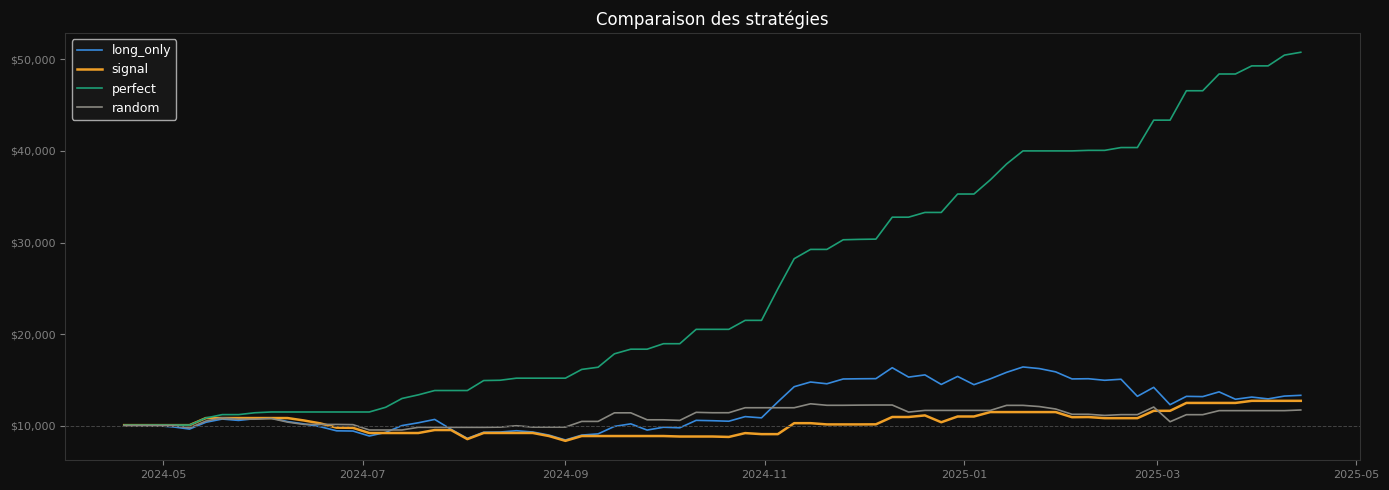

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#0f0f0f')

colors = {
    'perfect': '#1D9E75',
    'long_only': '#378ADD',
    'signal': '#EF9F27',
    'random': '#888780'
}

for strat in backtest['results']['strategy'].unique():
    s = backtest['results'][backtest['results']['strategy'] == strat]
    ax.plot(s['date'], s['portfolio_value'],
            label=strat, color=colors.get(strat, '#fff'),
            linewidth=1.8 if strat == 'signal' else 1.2)

ax.axhline(INITIAL_CAPITAL, color='#444', linewidth=0.7, linestyle='--')
ax.set_facecolor('#0f0f0f')
ax.tick_params(colors='gray', labelsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
ax.set_title('Comparaison des stratégies', color='white', fontsize=12)
for spine in ax.spines.values(): spine.set_color('#333')
plt.tight_layout()
plt.show()